# 📊 Sales Data Analysis Dashboard

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!"

# Import Libraries

In [2]:
# Path to your ZIP file

zip_path = r"C:\Users\amans\Downloads\train.csv (1).zip"

print("ZIP File:")
print(zip_path)

if os.path.exists(zip_path):
    print("\nFile found successfully!")
else:
    print("\nFile not found.")
    print("Please check the file path.")

ZIP File:
C:\Users\amans\Downloads\train.csv (1).zip

File found successfully!


In [3]:
# Folder where the ZIP file will be extracted

extract_folder = r"C:\Users\amans\Downloads\sales_analysis_data"

# Create folder if it doesn't exist
os.makedirs(extract_folder, exist_ok=True)

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")
print("\nExtracted files:")

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        print(os.path.join(root, file))

ZIP file extracted successfully!

Extracted files:
C:\Users\amans\Downloads\sales_analysis_data\train.csv


In [4]:
# Find all CSV files inside extracted folder

csv_files = []

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
C:\Users\amans\Downloads\sales_analysis_data\train.csv


# Load Dataset

In [5]:
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found inside the ZIP file.")

# Prefer train.csv if available
train_files = [file for file in csv_files if "train" in os.path.basename(file).lower()]

if len(train_files) > 0:
    csv_path = train_files[0]
else:
    csv_path = csv_files[0]

print("Loading file:")
print(csv_path)

df = pd.read_csv(csv_path)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

Loading file:
C:\Users\amans\Downloads\sales_analysis_data\train.csv

Dataset loaded successfully!
Shape: (9800, 18)


# First Five Rows

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Last Five Rows

In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra Strips",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


# Dataset Shape

In [8]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 9800
Number of Columns: 18


# Column Names

In [9]:
print("Column Names:")
print("=" * 50)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales


# Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

# Statistical Summary

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

dtype_summary

,Column,Data Type,Missing Values,Unique Values
0,Row ID,int64,0,9800
1,Order ID,object,0,4922
2,Order Date,object,0,1230
3,Ship Date,object,0,1326
4,Ship Mode,object,0,4
5,Customer ID,object,0,793
6,Customer Name,object,0,793
7,Segment,object,0,3
8,Country,object,0,1
9,City,object,0,529


# Data Cleaning

In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [14]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(9800, 18)


In [15]:
missing_data = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data.sort_values(
    by="Missing Values",
    ascending=False
)

missing_data

,Column,Missing Values,Missing Percentage
Postal Code,Postal Code,11,0.11
Row ID,Row ID,0,0.00
Order ID,Order ID,0,0.00
Product Name,Product Name,0,0.00
Sub-Category,Sub-Category,0,0.00
Category,Category,0,0.00
Product ID,Product ID,0,0.00
Region,Region,0,0.00
State,State,0,0.00
City,City,0,0.00


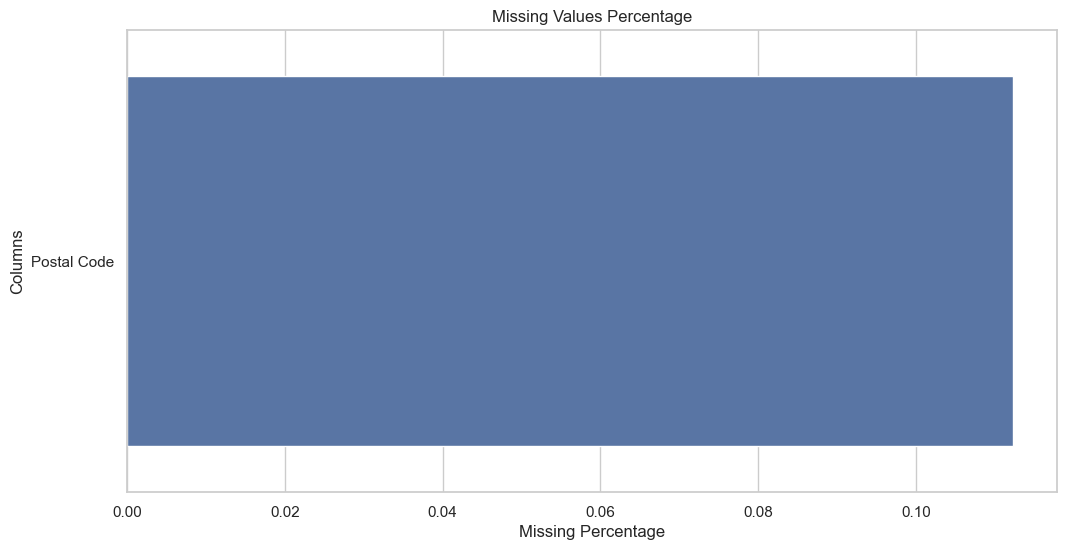

In [16]:
plt.figure(figsize=(12, 6))

missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

if len(missing_percent) > 0:
    sns.barplot(
        x=missing_percent.values,
        y=missing_percent.index
    )

    plt.title("Missing Values Percentage")
    plt.xlabel("Missing Percentage")
    plt.ylabel("Columns")
    plt.show()
else:
    print("No missing values found.")

In [17]:
# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [18]:
print("Total missing values:", df.isnull().sum().sum())

df.isnull().sum()

Total missing values: 0


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

# COLUMN NAME CLEANING

In [19]:
# Convert column names into a cleaner format

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales']


# Detect Date Column

In [20]:
# Try to identify date-related column

date_candidates = [
    col for col in df.columns
    if any(keyword in col for keyword in [
        "date", "order_date", "orderdate", "created", "time"
    ])
]

print("Possible date columns:")
print(date_candidates)

Possible date columns:
['order_date', 'ship_date']


# Convert Date Column

In [21]:
if len(date_candidates) > 0:
    
    date_column = date_candidates[0]
    
    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    )
    
    print("Date column selected:", date_column)
    
else:
    date_column = None
    print("No date column automatically detected.")

Date column selected: order_date


# Detect Numerical Columns

In [22]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
for column in numeric_columns:
    print("-", column)

Numerical columns:
- row_id
- postal_code
- sales


# Detect Categorical Columns

In [23]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
for column in categorical_columns:
    print("-", column)

Categorical columns:
- order_id
- ship_date
- ship_mode
- customer_id
- customer_name
- segment
- country
- city
- state
- region
- product_id
- category
- sub_category
- product_name


# EXPLORATORY DATA ANALYSIS

In [24]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_summary.sort_values(
    by="Unique Values",
    ascending=False
)

,Column,Unique Values
0,row_id,9800
17,sales,5757
1,order_id,4922
13,product_id,1861
16,product_name,1849
3,ship_date,1326
5,customer_id,793
6,customer_name,793
11,postal_code,626
9,city,529


In [25]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
row_id,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
postal_code,9800.0,55276.498571,32023.374393,1040.000,23223.000,58103.00,90008.000,99301.00
sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [26]:
for column in categorical_columns:
    
    print("\n" + "=" * 60)
    print("Column:", column)
    print("=" * 60)
    
    print(df[column].value_counts().head(10))


Column: order_id
order_id
CA-2018-100111    14
CA-2018-157987    12
CA-2017-165330    11
US-2017-108504    11
CA-2017-105732    10
CA-2016-131338    10
US-2016-126977    10
US-2017-114013     9
CA-2015-106439     9
US-2016-163433     9
Name: count, dtype: int64

Column: ship_date
ship_date
26/09/2018    34
06/12/2018    32
16/12/2016    31
15/09/2018    30
06/09/2018    30
21/11/2018    30
12/12/2018    30
13/09/2015    27
08/09/2018    27
18/11/2018    26
Name: count, dtype: int64

Column: ship_mode
ship_mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

Column: customer_id
customer_id
WB-21850    35
MA-17560    34
PP-18955    34
JL-15835    33
CK-12205    32
JD-15895    32
SV-20365    32
EP-13915    31
ZC-21910    31
AP-10915    31
Name: count, dtype: int64

Column: customer_name
customer_name
William Brown          35
Matt Abelman           34
Paul Prost             34
John Lee               33
Chloris Kastens

# SALES COLUMN IDENTIFICATION

In [27]:
sales_keywords = [
    "sales",
    "revenue",
    "amount",
    "total",
    "price",
    "profit",
    "income"
]

sales_candidates = []

for column in df.columns:
    if any(keyword in column for keyword in sales_keywords):
        if pd.api.types.is_numeric_dtype(df[column]):
            sales_candidates.append(column)

print("Possible sales/revenue columns:")
print(sales_candidates)

Possible sales/revenue columns:
['sales']


In [28]:
if len(sales_candidates) > 0:
    
    # Prefer exact sales/revenue columns
    preferred = [
        col for col in sales_candidates
        if col in ["sales", "revenue", "total_sales", "amount"]
    ]
    
    if len(preferred) > 0:
        sales_column = preferred[0]
    else:
        sales_column = sales_candidates[0]
    
    print("Selected sales column:", sales_column)

else:
    sales_column = None
    print("Sales column could not be automatically detected.")

Selected sales column: sales


# BASIC SALES ANALYSIS

# Total Sales

In [29]:
if sales_column:
    
    total_sales = df[sales_column].sum()
    average_sales = df[sales_column].mean()
    maximum_sales = df[sales_column].max()
    minimum_sales = df[sales_column].min()
    
    print("Sales Analysis")
    print("=" * 40)
    print(f"Total Sales      : {total_sales:,.2f}")
    print(f"Average Sales    : {average_sales:,.2f}")
    print(f"Maximum Sales    : {maximum_sales:,.2f}")
    print(f"Minimum Sales    : {minimum_sales:,.2f}")

Sales Analysis
Total Sales      : 2,261,536.78
Average Sales    : 230.77
Maximum Sales    : 22,638.48
Minimum Sales    : 0.44


# SALES DISTRIBUTION

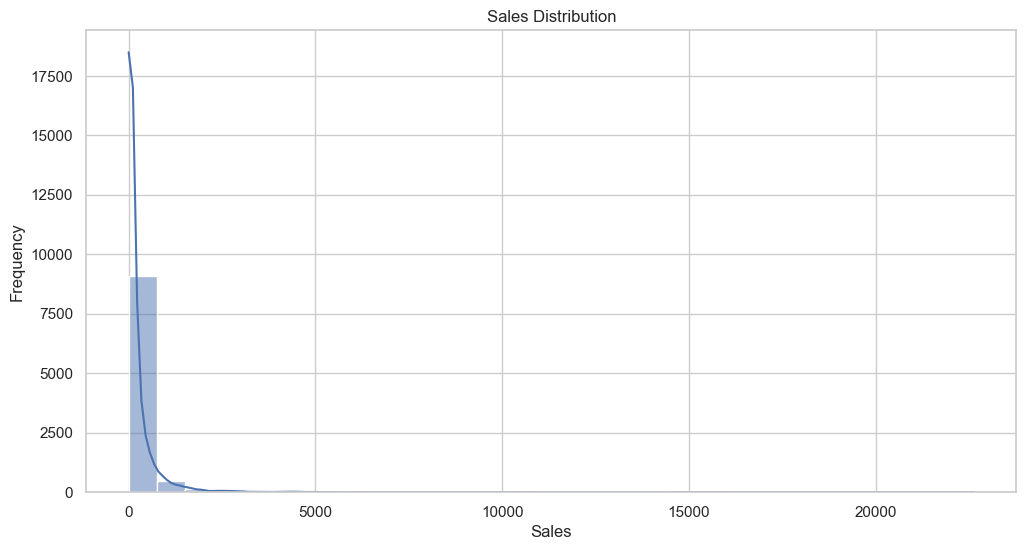

In [30]:
if sales_column:
    
    plt.figure(figsize=(12, 6))
    
    sns.histplot(
        df[sales_column],
        bins=30,
        kde=True
    )
    
    plt.title("Sales Distribution")
    plt.xlabel("Sales")
    plt.ylabel("Frequency")
    plt.show()

# TOP SALES RECORDS

In [31]:
if sales_column:
    
    top_sales = df.sort_values(
        by=sales_column,
        ascending=False
    ).head(10)
    
    top_sales

# Correlation Matrix

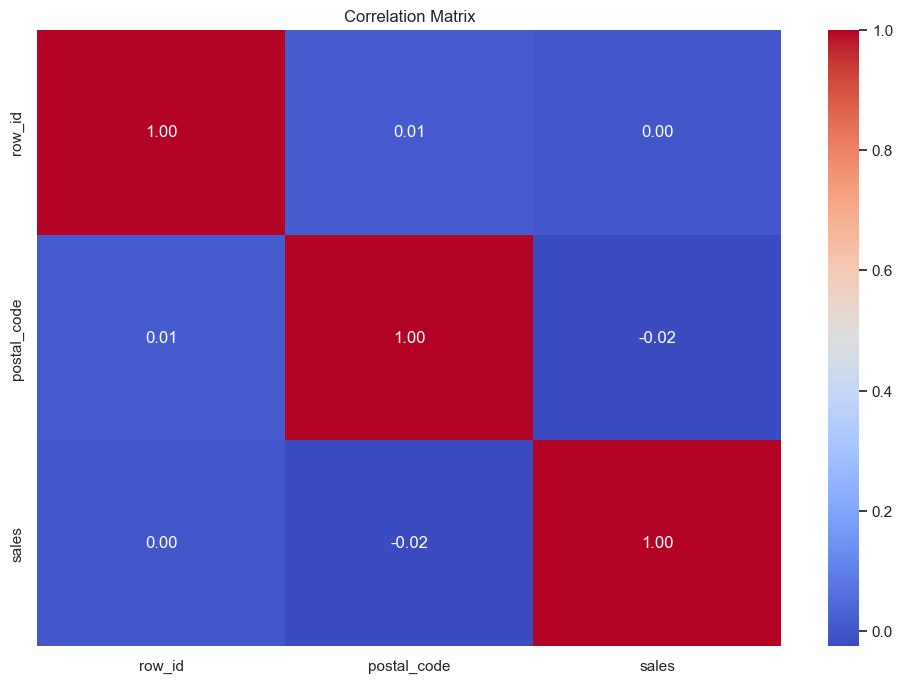

In [32]:
if len(numeric_columns) >= 2:
    
    correlation = df[numeric_columns].corr()
    
    plt.figure(figsize=(12, 8))
    
    sns.heatmap(
        correlation,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )
    
    plt.title("Correlation Matrix")
    plt.show()

# Find Category Column

In [33]:
category_keywords = [
    "category",
    "product_category",
    "subcategory",
    "segment",
    "type",
    "product"
]

category_candidates = []

for column in df.columns:
    if any(keyword in column for keyword in category_keywords):
        if df[column].nunique() < len(df) * 0.5:
            category_candidates.append(column)

print("Possible category columns:")
print(category_candidates)

Possible category columns:
['segment', 'product_id', 'category', 'sub_category', 'product_name']


# Category Sales Analysis

In [34]:
if sales_column and len(category_candidates) > 0:
    
    category_column = category_candidates[0]
    
    category_sales = (
        df.groupby(category_column)[sales_column]
        .sum()
        .sort_values(ascending=False)
    )
    
    print("Sales by Category:")
    display(category_sales)

Sales by Category:


segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: sales, dtype: float64

# Category Sales Visualization

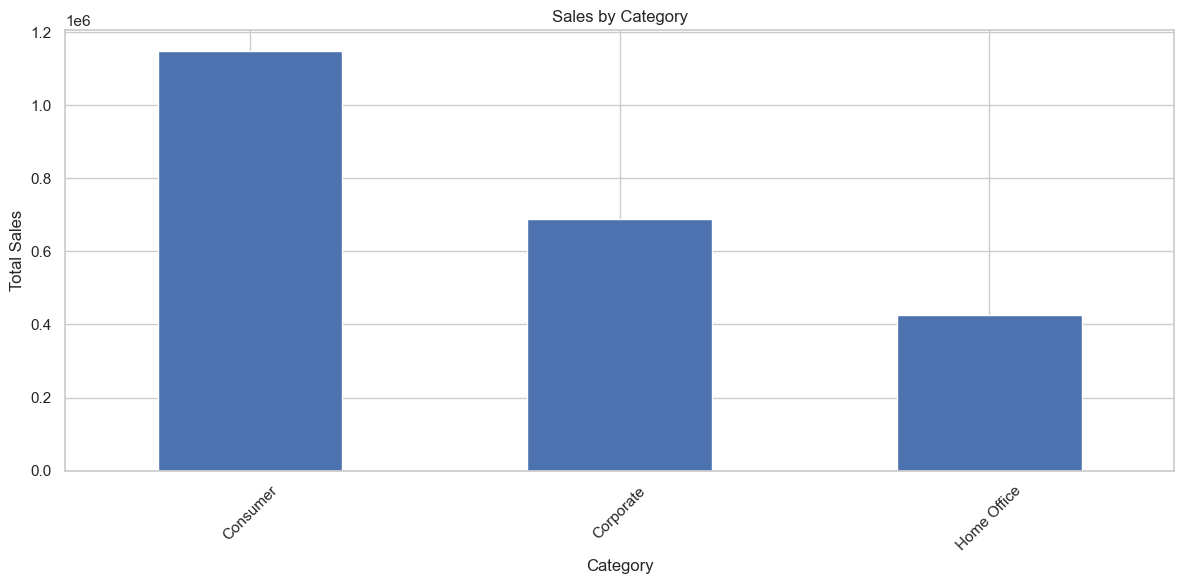

In [35]:
if sales_column and len(category_candidates) > 0:
    
    plt.figure(figsize=(12, 6))
    
    category_sales.plot(
        kind="bar"
    )
    
    plt.title("Sales by Category")
    plt.xlabel("Category")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# CUSTOMER ANALYSIS

In [37]:
customer_keywords = [
    "customer",
    "customer_id",
    "customerid",
    "client",
    "buyer"
]

customer_candidates = []

for column in df.columns:
    if any(keyword in column for keyword in customer_keywords):
        customer_candidates.append(column)

print("Possible customer columns:")
print(customer_candidates)

Possible customer columns:
['customer_id', 'customer_name']


In [38]:
if sales_column and len(customer_candidates) > 0:
    
    customer_column = customer_candidates[0]
    
    customer_sales = (
        df.groupby(customer_column)[sales_column]
        .sum()
        .sort_values(ascending=False)
    )
    
    print("Top 10 Customers by Sales")
    display(customer_sales.head(10))

Top 10 Customers by Sales


customer_id
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: sales, dtype: float64

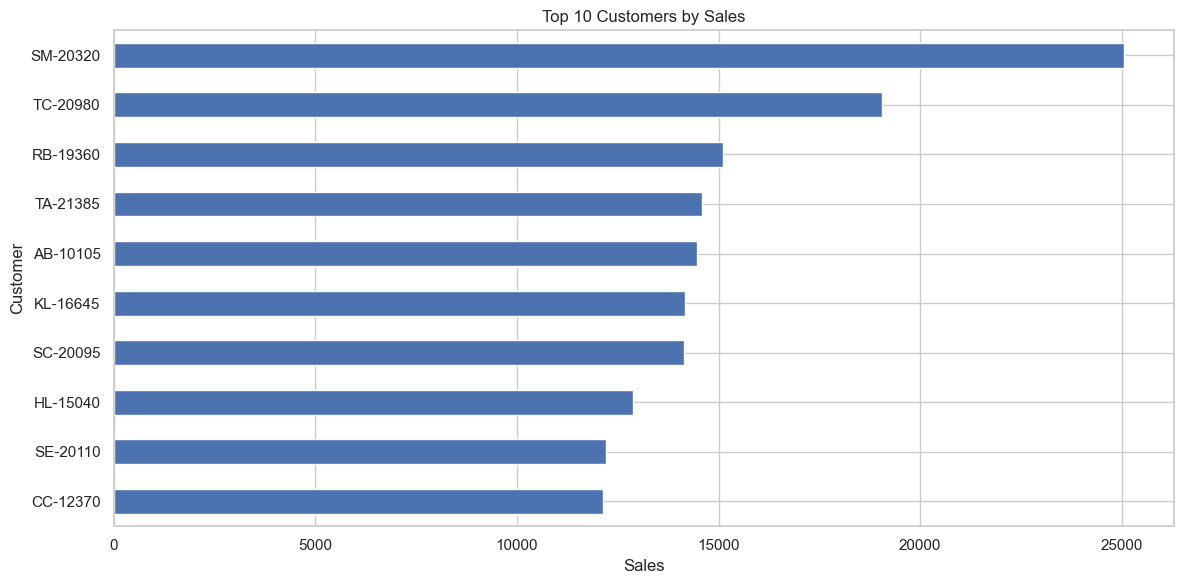

In [39]:
if sales_column and len(customer_candidates) > 0:
    
    top_customers = customer_sales.head(10)
    
    plt.figure(figsize=(12, 6))
    
    top_customers.sort_values().plot(
        kind="barh"
    )
    
    plt.title("Top 10 Customers by Sales")
    plt.xlabel("Sales")
    plt.ylabel("Customer")
    plt.tight_layout()
    plt.show()

# REGION ANALYSIS

In [40]:
region_keywords = [
    "region",
    "state",
    "city",
    "country",
    "location",
    "territory",
    "area"
]

region_candidates = []

for column in df.columns:
    if any(keyword in column for keyword in region_keywords):
        region_candidates.append(column)

print("Possible region columns:")
print(region_candidates)

Possible region columns:
['country', 'city', 'state', 'region']


In [41]:
if sales_column and len(region_candidates) > 0:
    
    region_column = region_candidates[0]
    
    region_sales = (
        df.groupby(region_column)[sales_column]
        .sum()
        .sort_values(ascending=False)
    )
    
    print("Sales by Region:")
    display(region_sales)

Sales by Region:


country
United States    2.261537e+06
Name: sales, dtype: float64

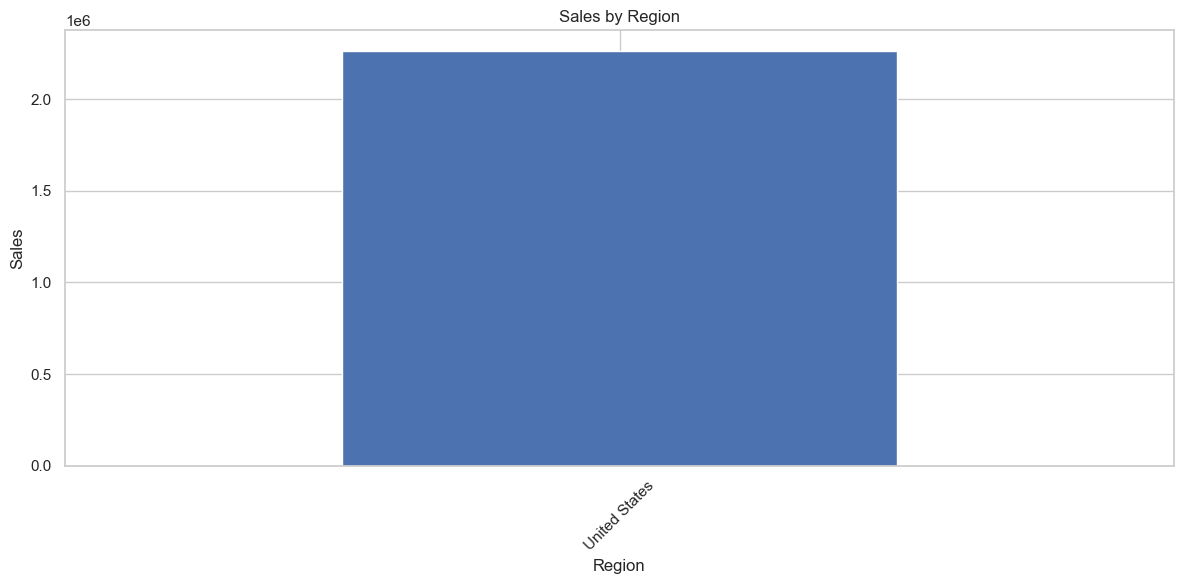

In [42]:
if sales_column and len(region_candidates) > 0:
    
    plt.figure(figsize=(12, 6))
    
    region_sales.head(15).plot(
        kind="bar"
    )
    
    plt.title("Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# TIME-SERIES SALES ANALYSIS

# Monthly Sales

In [43]:
if date_column and sales_column:
    
    temp_df = df.dropna(
        subset=[date_column, sales_column]
    ).copy()
    
    temp_df["year_month"] = (
        temp_df[date_column]
        .dt.to_period("M")
        .astype(str)
    )
    
    monthly_sales = (
        temp_df.groupby("year_month")[sales_column]
        .sum()
    )
    
    display(monthly_sales)

year_month
2015-01    19546.1630
2015-02    11678.9940
2015-03     6716.0440
2015-04    12455.4820
2015-05    15165.0510
2015-06    11884.1690
2015-07    10075.7400
2015-08    26797.7630
2015-09    17158.9320
2015-10    10112.6410
2015-11    18349.7640
2015-12    17045.8427
2016-01    17701.6864
2016-02    13018.3150
2016-03    12207.4066
2016-04    11963.6960
2016-05    10483.4820
2016-06    13026.6682
2016-07    10706.7200
2016-08    22782.5770
2016-09    16484.9010
2016-10    12293.0380
2016-11    12139.0395
2016-12     9761.3330
2017-01    26342.5410
2017-02    42967.9150
2017-03    25982.2870
2017-04    19472.1640
2017-05    22649.3888
2017-06    14050.1430
2017-07    16501.0070
2017-08    24156.3226
2017-09     9789.6620
2017-10    22599.7820
2017-11    20378.2400
2017-12    21365.1485
2018-01    27367.5920
2018-02    36285.9360
2018-03    26882.9530
2018-04    21203.6070
2018-05    15979.1570
2018-06    12138.1558
2018-07    25110.4795
2018-08    26823.6900
2018-09    23148.8700

# Monthly Sales Trend

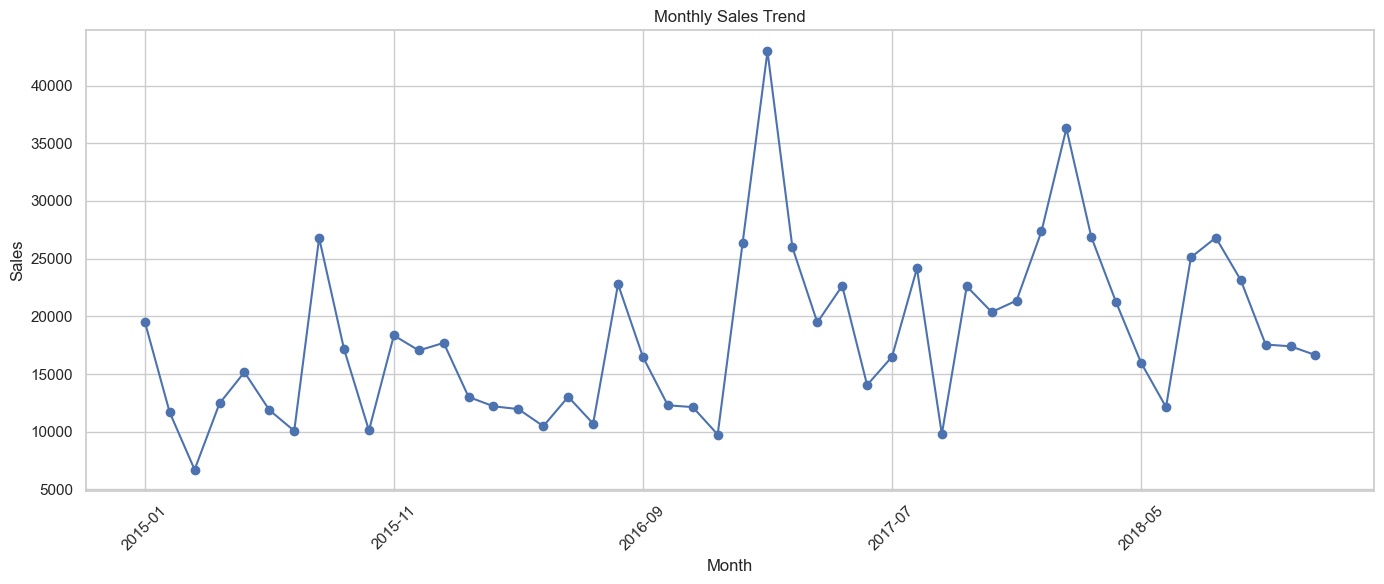

In [44]:
if date_column and sales_column:
    
    plt.figure(figsize=(14, 6))
    
    monthly_sales.plot(
        marker="o"
    )
    
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# YEARLY SALES

In [45]:
if date_column and sales_column:
    
    temp_df["year"] = temp_df[date_column].dt.year
    
    yearly_sales = (
        temp_df.groupby("year")[sales_column]
        .sum()
    )
    
    display(yearly_sales)

year
2015    176986.5857
2016    162568.8627
2017    266254.6009
2018    266553.0743
Name: sales, dtype: float64

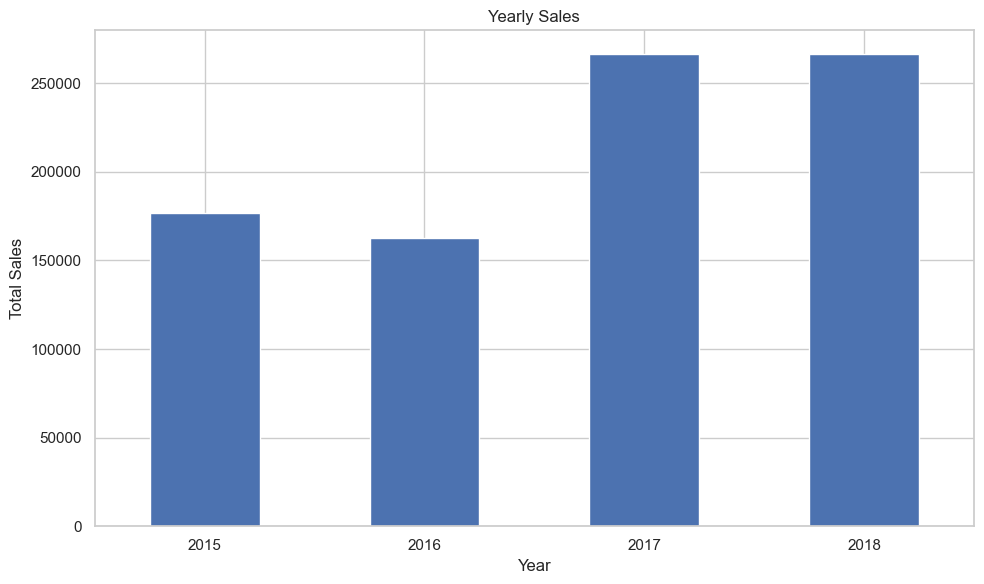

In [46]:
if date_column and sales_column:
    
    plt.figure(figsize=(10, 6))
    
    yearly_sales.plot(
        kind="bar"
    )
    
    plt.title("Yearly Sales")
    plt.xlabel("Year")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Daily Sales

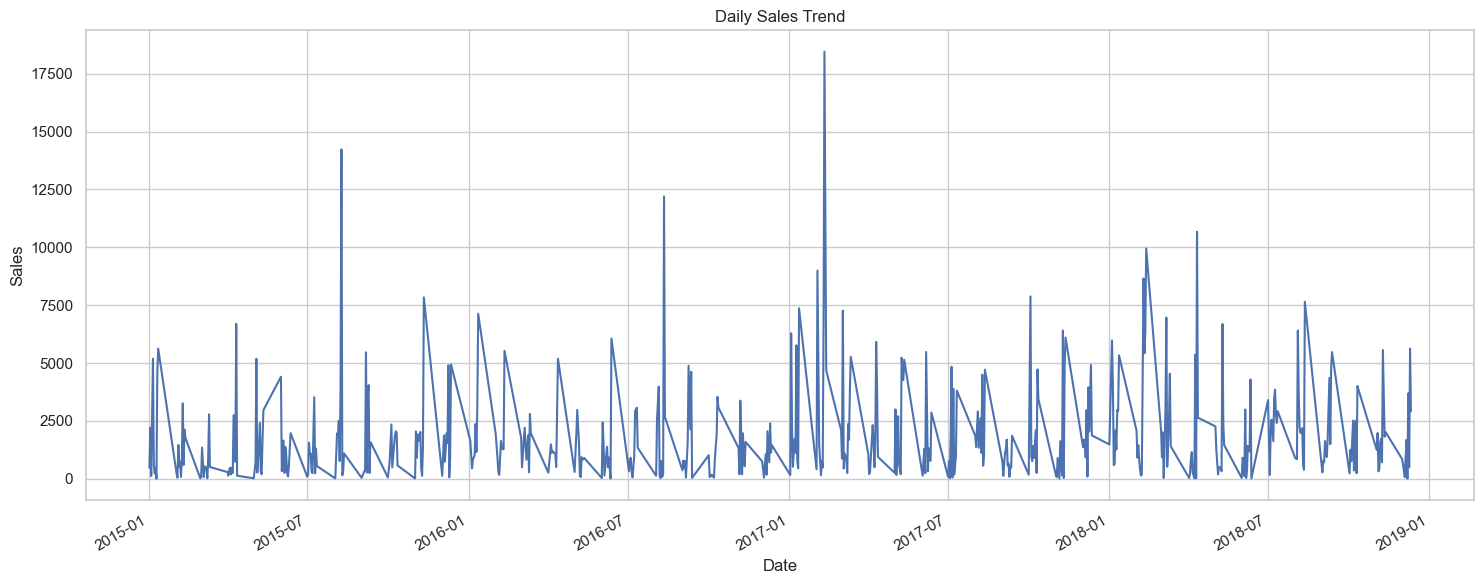

In [49]:
if date_column and sales_column:
    
    daily_sales = (
        temp_df.groupby(date_column)[sales_column]
        .sum()
    )
    
    plt.figure(figsize=(15, 6))
    
    daily_sales.plot()
    
    plt.title("Daily Sales Trend")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()

In [50]:
if date_column and sales_column:
    
    temp_df["day_of_week"] = (
        temp_df[date_column]
        .dt.day_name()
    )
    
    weekday_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
    
    weekday_sales = (
        temp_df.groupby("day_of_week")[sales_column]
        .sum()
        .reindex(weekday_order)
    )
    
    display(weekday_sales)

day_of_week
Monday       126530.0140
Tuesday      125724.4114
Wednesday    123395.8803
Thursday     135621.3663
Friday       128325.6277
Saturday     109064.5395
Sunday       123701.2844
Name: sales, dtype: float64

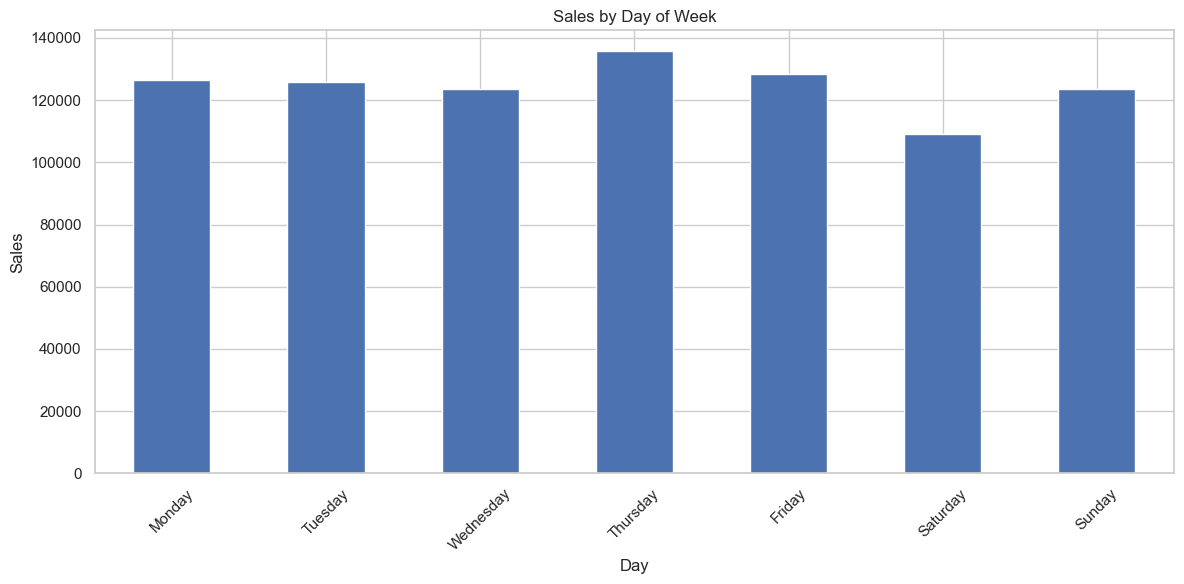

In [51]:
if date_column and sales_column:
    
    plt.figure(figsize=(12, 6))
    
    weekday_sales.plot(
        kind="bar"
    )
    
    plt.title("Sales by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# PROFIT ANALYSIS

In [52]:
profit_candidates = [
    column for column in df.columns
    if "profit" in column.lower()
    and pd.api.types.is_numeric_dtype(df[column])
]

print("Possible profit columns:")
print(profit_candidates)

Possible profit columns:
[]


In [54]:
if len(profit_candidates) > 0:
    
    profit_column = profit_candidates[0]
    
    total_profit = df[profit_column].sum()
    average_profit = df[profit_column].mean()
    
    print("Total Profit:", round(total_profit, 2))
    print("Average Profit:", round(average_profit, 2))

In [57]:
if sales_column and len(profit_candidates) > 0:
    
    profit_column = profit_candidates[0]
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df,
        x=sales_column,
        y=profit_column
    )
    
    plt.title("Sales vs Profit")
    plt.xlabel("Sales")
    plt.ylabel("Profit")
    plt.show()

In [56]:
product_candidates = [
    column for column in df.columns
    if any(keyword in column.lower() for keyword in [
        "product",
        "item",
        "sku"
    ])
]

print("Possible product columns:")
print(product_candidates)

Possible product columns:
['product_id', 'product_name']


In [58]:
if sales_column and len(product_candidates) > 0:
    
    product_column = product_candidates[0]
    
    product_sales = (
        df.groupby(product_column)[sales_column]
        .sum()
        .sort_values(ascending=False)
    )
    
    print("Top 10 Products:")
    display(product_sales.head(10))

Top 10 Products:


product_id
TEC-CO-10004722    61599.824
OFF-BI-10003527    27453.384
TEC-MA-10002412    22638.480
FUR-CH-10002024    21870.576
OFF-BI-10001359    19823.479
OFF-BI-10000545    19024.500
TEC-CO-10001449    18839.686
TEC-MA-10001127    18374.895
OFF-BI-10004995    17965.068
OFF-SU-10000151    17030.312
Name: sales, dtype: float64

# TOP PRODUCTS

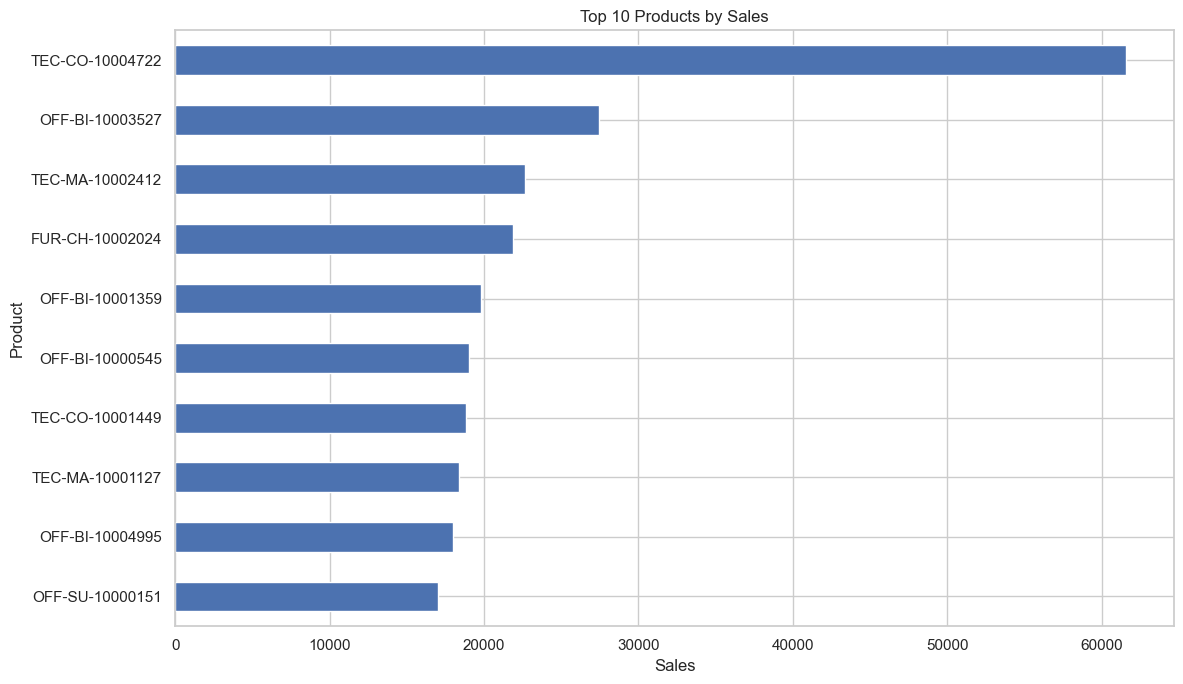

In [59]:
if sales_column and len(product_candidates) > 0:
    
    top_products = product_sales.head(10)
    
    plt.figure(figsize=(12, 7))
    
    top_products.sort_values().plot(
        kind="barh"
    )
    
    plt.title("Top 10 Products by Sales")
    plt.xlabel("Sales")
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

# OUTLIER DETECTION

In [60]:
if sales_column:
    
    Q1 = df[sales_column].quantile(0.25)
    Q3 = df[sales_column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[sales_column] < lower_limit) |
        (df[sales_column] > upper_limit)
    ]
    
    print("Number of sales outliers:", len(outliers))
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)

Number of sales outliers: 1145
Lower Limit: -272.7875000000001
Upper Limit: 500.6405000000001


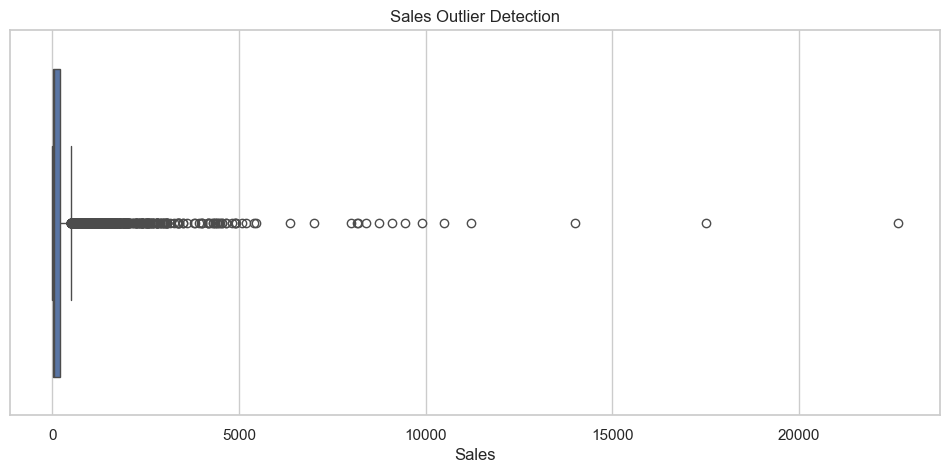

In [61]:
if sales_column:
    
    plt.figure(figsize=(12, 5))
    
    sns.boxplot(
        x=df[sales_column]
    )
    
    plt.title("Sales Outlier Detection")
    plt.xlabel("Sales")
    plt.show()

# KPI CALCULATION

In [62]:
print("=" * 60)
print("                 BUSINESS KPI DASHBOARD")
print("=" * 60)

if sales_column:
    
    print(f"\nTotal Sales       : {df[sales_column].sum():,.2f}")
    print(f"Average Sales     : {df[sales_column].mean():,.2f}")
    print(f"Highest Sale      : {df[sales_column].max():,.2f}")
    print(f"Lowest Sale       : {df[sales_column].min():,.2f}")

if len(customer_candidates) > 0:
    print(f"Unique Customers  : {df[customer_candidates[0]].nunique():,}")

if len(product_candidates) > 0:
    print(f"Unique Products   : {df[product_candidates[0]].nunique():,}")

if len(region_candidates) > 0:
    print(f"Unique Regions    : {df[region_candidates[0]].nunique():,}")

if len(profit_candidates) > 0:
    print(f"Total Profit      : {df[profit_candidates[0]].sum():,.2f}")

print("\n" + "=" * 60)

                 BUSINESS KPI DASHBOARD

Total Sales       : 2,261,536.78
Average Sales     : 230.77
Highest Sale      : 22,638.48
Lowest Sale       : 0.44
Unique Customers  : 793
Unique Products   : 1,861
Unique Regions    : 1



# SALES DASHBOARD

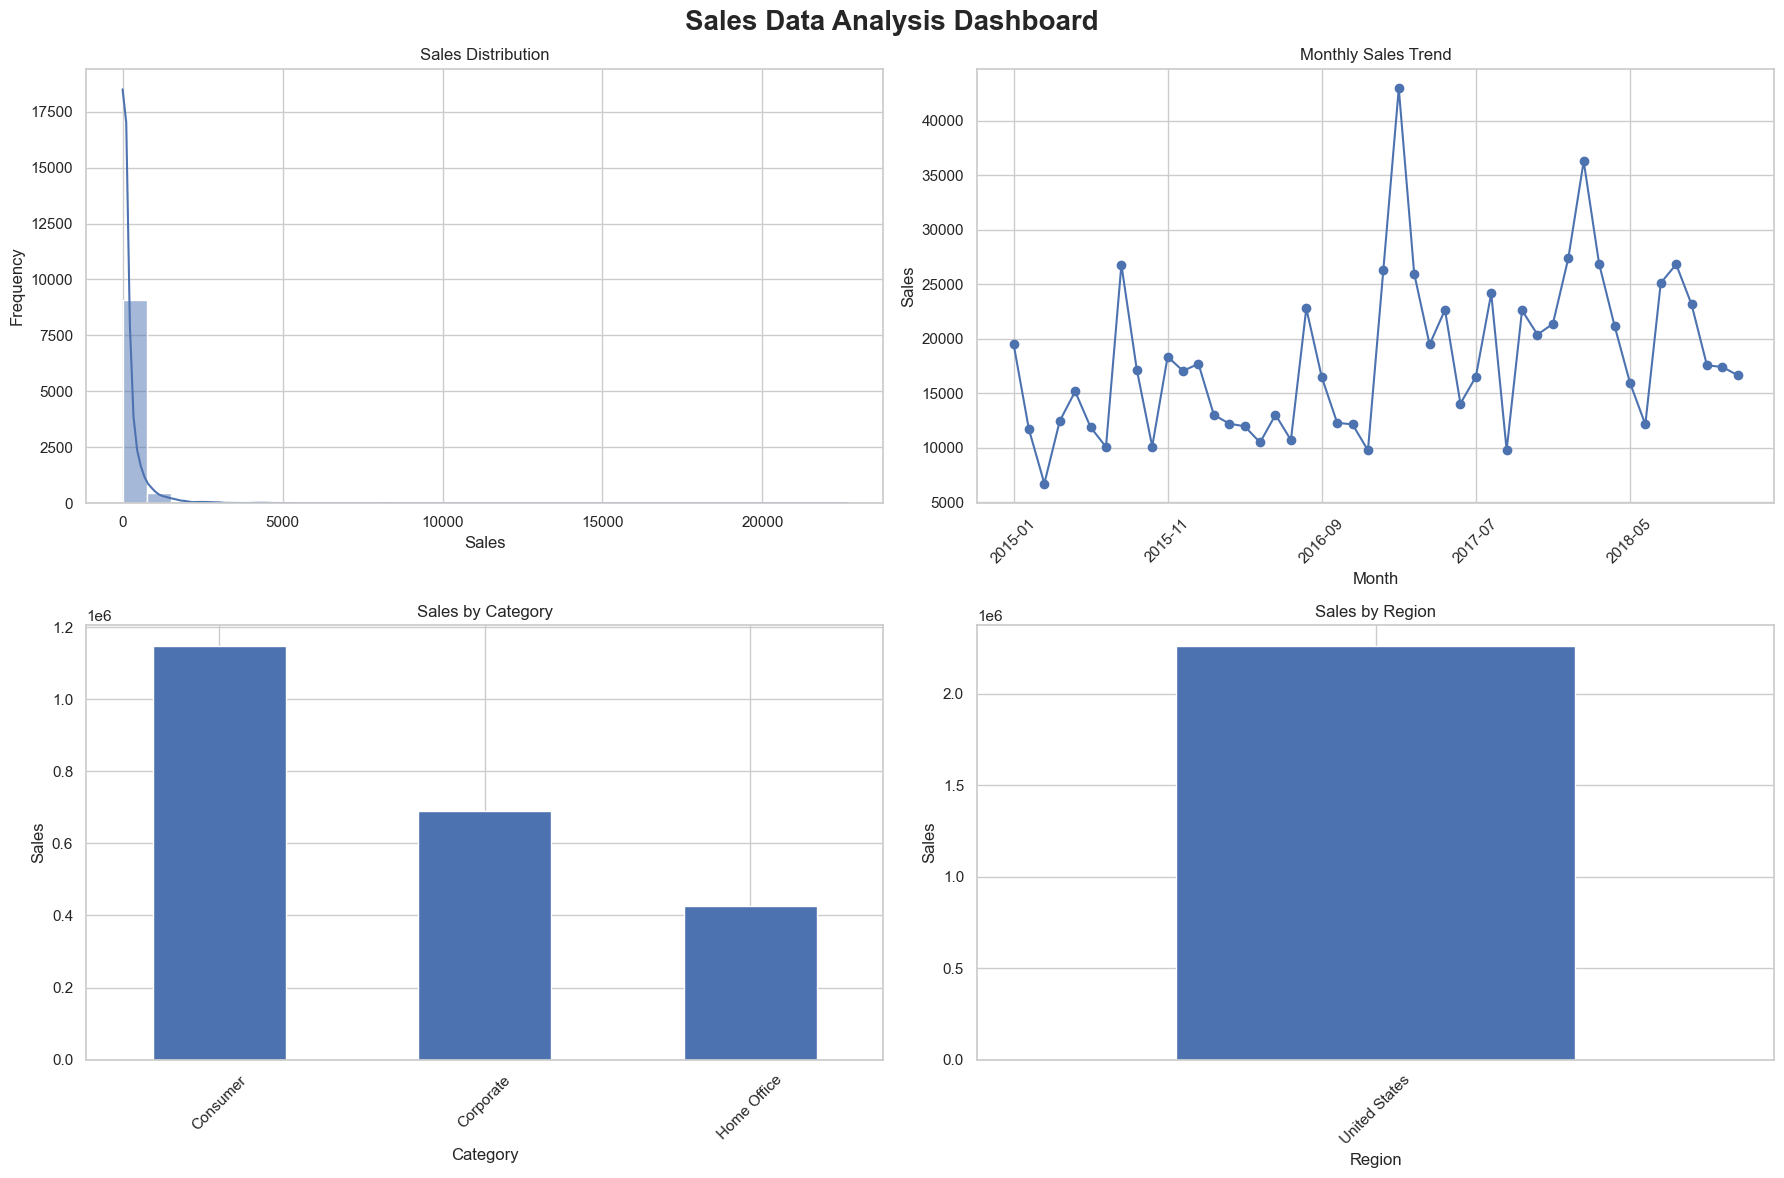

In [63]:
fig = plt.figure(figsize=(18, 12))

# ---------------------------------------------------------
# 1. Sales Distribution
# ---------------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

if sales_column:
    sns.histplot(
        df[sales_column],
        bins=30,
        kde=True,
        ax=ax1
    )
    
    ax1.set_title("Sales Distribution")
    ax1.set_xlabel("Sales")
    ax1.set_ylabel("Frequency")


# ---------------------------------------------------------
# 2. Monthly Sales
# ---------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

if date_column and sales_column:
    
    monthly_sales.plot(
        ax=ax2,
        marker="o"
    )
    
    ax2.set_title("Monthly Sales Trend")
    ax2.set_xlabel("Month")
    ax2.set_ylabel("Sales")
    ax2.tick_params(axis="x", rotation=45)


# ---------------------------------------------------------
# 3. Category Sales
# ---------------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

if sales_column and len(category_candidates) > 0:
    
    category_sales.head(10).plot(
        kind="bar",
        ax=ax3
    )
    
    ax3.set_title("Sales by Category")
    ax3.set_xlabel("Category")
    ax3.set_ylabel("Sales")
    ax3.tick_params(axis="x", rotation=45)


# ---------------------------------------------------------
# 4. Regional Sales
# ---------------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

if sales_column and len(region_candidates) > 0:
    
    region_sales.head(10).plot(
        kind="bar",
        ax=ax4
    )
    
    ax4.set_title("Sales by Region")
    ax4.set_xlabel("Region")
    ax4.set_ylabel("Sales")
    ax4.tick_params(axis="x", rotation=45)


plt.suptitle(
    "Sales Data Analysis Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# AUTOMATIC BUSINESS INSIGHTS

In [64]:
print("=" * 70)
print("                    BUSINESS INSIGHTS")
print("=" * 70)

# Total sales
if sales_column:
    
    print("\n1. SALES PERFORMANCE")
    print("-" * 50)
    
    total_sales = df[sales_column].sum()
    average_sales = df[sales_column].mean()
    
    print(f"Total sales generated: {total_sales:,.2f}")
    print(f"Average transaction value: {average_sales:,.2f}")


# Category insight
if sales_column and len(category_candidates) > 0:
    
    print("\n2. CATEGORY PERFORMANCE")
    print("-" * 50)
    
    best_category = category_sales.idxmax()
    best_category_sales = category_sales.max()
    
    print(f"Highest-performing category: {best_category}")
    print(f"Sales generated: {best_category_sales:,.2f}")


# Region insight
if sales_column and len(region_candidates) > 0:
    
    print("\n3. REGIONAL PERFORMANCE")
    print("-" * 50)
    
    best_region = region_sales.idxmax()
    best_region_sales = region_sales.max()
    
    print(f"Highest-performing region: {best_region}")
    print(f"Sales generated: {best_region_sales:,.2f}")


# Product insight
if sales_column and len(product_candidates) > 0:
    
    print("\n4. PRODUCT PERFORMANCE")
    print("-" * 50)
    
    best_product = product_sales.idxmax()
    best_product_sales = product_sales.max()
    
    print(f"Top-selling product: {best_product}")
    print(f"Sales generated: {best_product_sales:,.2f}")


# Customer insight
if sales_column and len(customer_candidates) > 0:
    
    print("\n5. CUSTOMER PERFORMANCE")
    print("-" * 50)
    
    top_customer = customer_sales.idxmax()
    top_customer_sales = customer_sales.max()
    
    print(f"Highest-value customer: {top_customer}")
    print(f"Sales generated: {top_customer_sales:,.2f}")


# Time insight
if date_column and sales_column:
    
    print("\n6. TIME TREND")
    print("-" * 50)
    
    best_month = monthly_sales.idxmax()
    best_month_sales = monthly_sales.max()
    
    print(f"Highest-sales month: {best_month}")
    print(f"Sales generated: {best_month_sales:,.2f}")


print("\n" + "=" * 70)
print("Analysis completed successfully!")
print("=" * 70)

                    BUSINESS INSIGHTS

1. SALES PERFORMANCE
--------------------------------------------------
Total sales generated: 2,261,536.78
Average transaction value: 230.77

2. CATEGORY PERFORMANCE
--------------------------------------------------
Highest-performing category: Consumer
Sales generated: 1,148,060.53

3. REGIONAL PERFORMANCE
--------------------------------------------------
Highest-performing region: United States
Sales generated: 2,261,536.78

4. PRODUCT PERFORMANCE
--------------------------------------------------
Top-selling product: TEC-CO-10004722
Sales generated: 61,599.82

5. CUSTOMER PERFORMANCE
--------------------------------------------------
Highest-value customer: SM-20320
Sales generated: 25,043.05

6. TIME TREND
--------------------------------------------------
Highest-sales month: 2017-02
Sales generated: 42,967.92

Analysis completed successfully!


In [65]:
output_path = r"C:\Users\amans\Downloads\cleaned_sales_data.csv"

df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
C:\Users\amans\Downloads\cleaned_sales_data.csv


In [66]:
summary = {}

if sales_column:
    summary["Total Sales"] = df[sales_column].sum()
    summary["Average Sales"] = df[sales_column].mean()
    summary["Maximum Sales"] = df[sales_column].max()
    summary["Minimum Sales"] = df[sales_column].min()

if len(profit_candidates) > 0:
    summary["Total Profit"] = df[profit_candidates[0]].sum()

if len(customer_candidates) > 0:
    summary["Unique Customers"] = df[customer_candidates[0]].nunique()

if len(product_candidates) > 0:
    summary["Unique Products"] = df[product_candidates[0]].nunique()

if len(region_candidates) > 0:
    summary["Unique Regions"] = df[region_candidates[0]].nunique()

summary_df = pd.DataFrame(
    summary.items(),
    columns=["KPI", "Value"]
)

summary_df

,KPI,Value
0,Total Sales,2.261537e+06
1,Average Sales,2.307691e+02
2,Maximum Sales,2.263848e+04
3,Minimum Sales,4.440000e-01
4,Unique Customers,7.930000e+02
5,Unique Products,1.861000e+03
6,Unique Regions,1.000000e+00


In [67]:
print("""
============================================================
                 PROJECT CONCLUSION
============================================================

The Sales Data Analysis project was completed using Python.

Major activities performed:

1. Data Extraction
   - Extracted the dataset from ZIP format.

2. Data Cleaning
   - Removed duplicate records.
   - Handled missing values.
   - Standardized column names.
   - Converted date columns.

3. Exploratory Data Analysis
   - Analyzed numerical and categorical variables.
   - Studied sales distributions.
   - Identified correlations.
   - Detected outliers.

4. Sales Analysis
   - Calculated total and average sales.
   - Analyzed sales by category.
   - Analyzed sales by region.
   - Identified top products and customers.

5. Time-Series Analysis
   - Analyzed daily sales.
   - Analyzed monthly sales.
   - Analyzed yearly sales.
   - Studied sales by day of week.

6. Visualization
   - Created sales distribution charts.
   - Created category charts.
   - Created regional charts.
   - Created sales trend charts.
   - Created KPI dashboard.

7. Business Insights
   - Identified high-performing categories.
   - Identified high-performing regions.
   - Identified top products.
   - Identified high-value customers.
   - Identified high-sales periods.

============================================================
                 PROJECT COMPLETED
============================================================
""")


                 PROJECT CONCLUSION

The Sales Data Analysis project was completed using Python.

Major activities performed:

1. Data Extraction
   - Extracted the dataset from ZIP format.

2. Data Cleaning
   - Removed duplicate records.
   - Handled missing values.
   - Standardized column names.
   - Converted date columns.

3. Exploratory Data Analysis
   - Analyzed numerical and categorical variables.
   - Studied sales distributions.
   - Identified correlations.
   - Detected outliers.

4. Sales Analysis
   - Calculated total and average sales.
   - Analyzed sales by category.
   - Analyzed sales by region.
   - Identified top products and customers.

5. Time-Series Analysis
   - Analyzed daily sales.
   - Analyzed monthly sales.
   - Analyzed yearly sales.
   - Studied sales by day of week.

6. Visualization
   - Created sales distribution charts.
   - Created category charts.
   - Created regional charts.
   - Created sales trend charts.
   - Created KPI dashboard.

7. Busin